In [3]:
import pandas as pd

# === Load and preprocess ===
df = pd.read_csv("spearman_duplicates_grouped_norepeat_Cas9_mlp.csv")

# Fill down missing edge names
df['Feature'] = df['Feature'].fillna(method='ffill')

# Preserve original feature order
original_order = df['Feature'].dropna().unique()
df['Feature'] = pd.Categorical(df['Feature'], categories=original_order, ordered=True)

# Group and filter
results = []

for feature in original_order:
    group = df[df['Feature'] == feature]
    spearman_values = group["Spearman Correlation"].dropna()

    if len(spearman_values) >= 2:
        q1 = spearman_values.quantile(0.25)
        q3 = spearman_values.quantile(0.75)
        median = spearman_values.median()

        if q1 > 0:
            results.append((feature, round(q1, 3), round(q3, 3), round(median, 3)))

# Output as DataFrame with original order preserved
iqr_df = pd.DataFrame(results, columns=["Feature", "Q1", "Q3", "Median Spearman Correlation"])
iqr_df["Feature"] = pd.Categorical(iqr_df["Feature"], categories=original_order, ordered=True)
iqr_df = iqr_df.sort_values("Feature")

# Display and save
print(iqr_df)
iqr_df.to_csv("features_with_positive_IQR_Cas9_mlp.csv", index=False)


                               Feature     Q1     Q3  \
0                         crRNA spacer  0.974  0.994   
1  bh_maximal consecutive paired bases  0.658  0.972   
2                           bh_5' stem  0.251  0.689   
3                           bh_3' stem  0.809  0.856   
4                         dsDNA target  0.868  0.973   
5  ah_maximal consecutive paired bases  0.089  0.964   
6                           ah_3' stem  0.594  0.939   
7                       central region  0.903  0.988   

   Median Spearman Correlation  
0                        0.991  
1                        0.905  
2                        0.535  
3                        0.846  
4                        0.963  
5                        0.417  
6                        0.780  
7                        0.983  


/var/folders/8p/2p_212ld2qvgjsycxk_lmmg00000gn/T/ipykernel_58898/326493243.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Feature'] = df['Feature'].fillna(method='ffill')


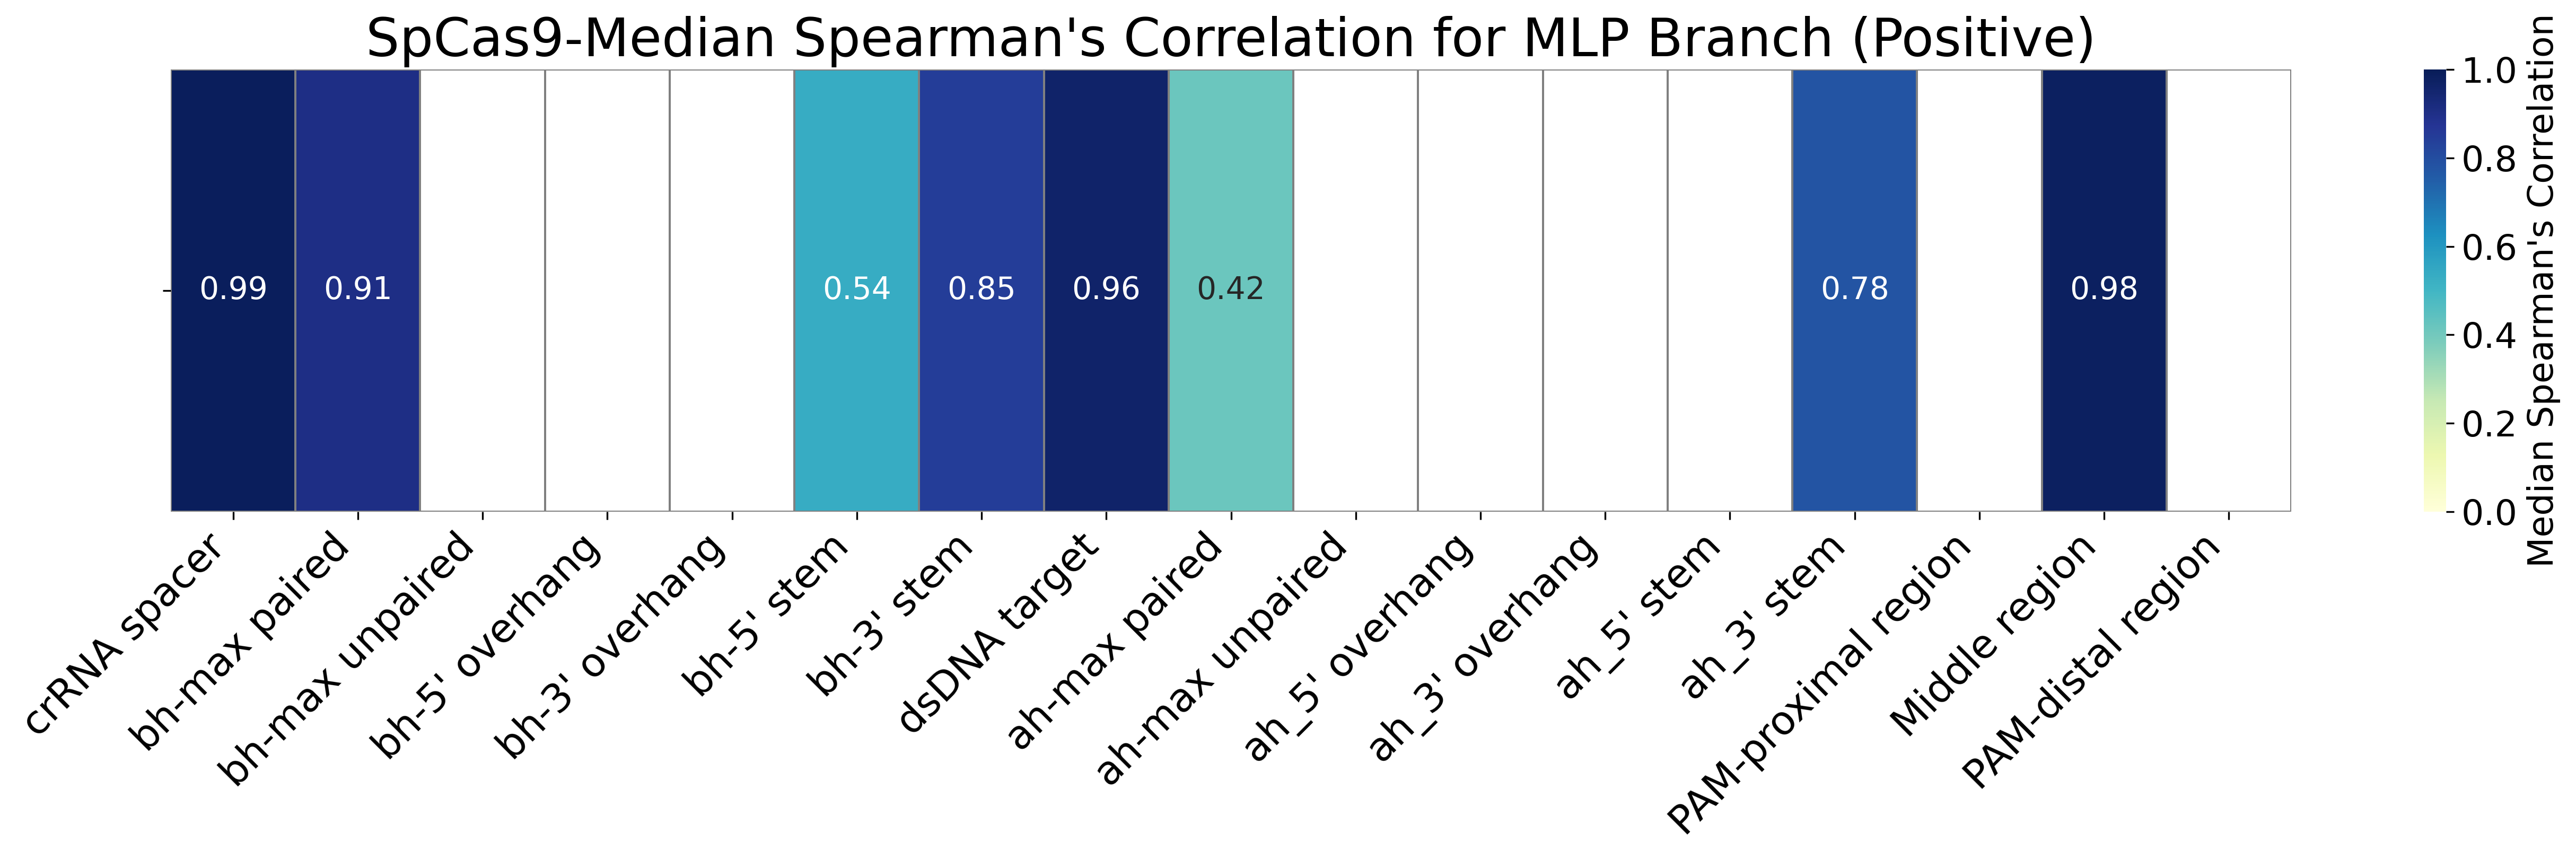

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---- desired full feature order (17 columns) ----
feature_order = [
    "crRNA spacer",
    "bh_maximal consecutive paired bases",
    "bh_maximal consecutive unpaired bases",
    "bh_5' overhang",
    "bh_3' overhang",
    "bh_5' stem",
    "bh_3' stem",
    "dsDNA target",
    "ah_maximal consecutive paired bases",
    "ah_maximal consecutive unpaired bases",
    "ah_5' overhang",
    "ah_3' overhang",
    "ah_5' stem",
    "ah_3' stem",
    "PAM-proximal region",
    "central region",
    "PAM-distal region"
]

csv_path = "features_with_positive_IQR_Cas9_mlp.csv"
value_col = "Median Spearman Correlation"   # change if your column name differs
feature_col = "Feature"                     # change if your feature-name column differs

# ---- load ----
df = pd.read_csv(csv_path)

# Optional: if duplicates exist, average them
df = df.groupby(feature_col, as_index=False)[value_col].mean()

# ---- build a 1x17 table: row label "MLP", columns are the 17 features ----
# Map available features into a Series indexed by Feature name
s = df.set_index(feature_col)[value_col]

# Reindex to force all 17 features to exist; missing -> NaN
s = s.reindex(feature_order)

heatmap_data = pd.DataFrame([s.values], index=[""], columns=feature_order)

# ---- plot (NaN will be blank if masked) ----
mask = heatmap_data.isna()

fig, ax = plt.subplots(figsize=(18, 5.5), dpi=300)
hm = sns.heatmap(
    heatmap_data,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0, vmax=1,
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={"label": "Median Spearman's Correlation"},
    annot_kws={"fontsize": 14},
    ax=ax
)

ax.set_ylabel("")  # 1-row heatmap; optional
ax.set_xlabel("")
ax.set_title("SpCas9-Median Spearman's Correlation for MLP Branch (Positive)", fontsize=24)

# Rotate x tick labels + align to the right (NOTE: use set_xticklabels for alignment)
short_labels = [
    "crRNA spacer",
    "bh-max paired",
    "bh-max unpaired",
    "bh-5' overhang",
    "bh-3' overhang",
    "bh-5' stem",
    "bh-3' stem",
    "dsDNA target",
    "ah-max paired",
    "ah-max unpaired",
    "ah_5' overhang",
    "ah_3' overhang",
    "ah_5' stem",
    "ah_3' stem",
    "PAM-proximal region",
    "Middle region",
    "PAM-distal region"
]

ax.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=18)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=12)

# Colorbar font sizes
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=16)
cbar.set_label("Median Spearman's Correlation", fontsize=16)

plt.tight_layout()
plt.show()


In [5]:
import pandas as pd

# === Load and preprocess ===
df = pd.read_csv("spearman_duplicates_grouped_norepeat_Cas9_cnn1.csv")

# Fill down missing edge names
df['Feature'] = df['Feature'].fillna(method='ffill')

# Preserve original feature order
original_order = df['Feature'].dropna().unique()
df['Feature'] = pd.Categorical(df['Feature'], categories=original_order, ordered=True)

# Group and filter
results = []

for feature in original_order:
    group = df[df['Feature'] == feature]
    spearman_values = group["Spearman Correlation"].dropna()

    if len(spearman_values) >= 2:
        q1 = spearman_values.quantile(0.25)
        q3 = spearman_values.quantile(0.75)
        median = spearman_values.median()

        if q1 > 0:
            results.append((feature, round(q1, 3), round(q3, 3), round(median, 3)))

# Output as DataFrame with original order preserved
iqr_df = pd.DataFrame(results, columns=["Feature", "Q1", "Q3", "Median Spearman Correlation"])
iqr_df["Feature"] = pd.Categorical(iqr_df["Feature"], categories=original_order, ordered=True)
iqr_df = iqr_df.sort_values("Feature")

# Display and save
print(iqr_df)
iqr_df.to_csv("features_with_positive_IQR_Cas9_cnn1.csv", index=False)


    Feature     Q1     Q3  Median Spearman Correlation
0    Pos1_A  0.421  0.545                        0.488
1    Pos1_G  0.751  0.782                        0.782
2    Pos1_T  0.171  0.549                        0.298
3    Pos2_A  0.554  0.693                        0.671
4    Pos2_C  0.680  0.776                        0.771
5    Pos3_A  0.640  0.694                        0.681
6    Pos3_G  0.334  0.684                        0.576
7    Pos3_T  0.148  0.498                        0.192
8    Pos4_A  0.246  0.488                        0.347
9    Pos4_C  0.156  0.623                        0.176
10   Pos4_G  0.742  0.766                        0.756
11   Pos5_A  0.268  0.501                        0.407
12   Pos5_C  0.689  0.769                        0.737
13   Pos5_G  0.194  0.526                        0.302
14   Pos6_A  0.142  0.591                        0.461
15   Pos6_C  0.666  0.773                        0.706
16   Pos6_G  0.682  0.724                        0.722
17   Pos7_

/var/folders/8p/2p_212ld2qvgjsycxk_lmmg00000gn/T/ipykernel_58898/2795511012.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Feature'] = df['Feature'].fillna(method='ffill')


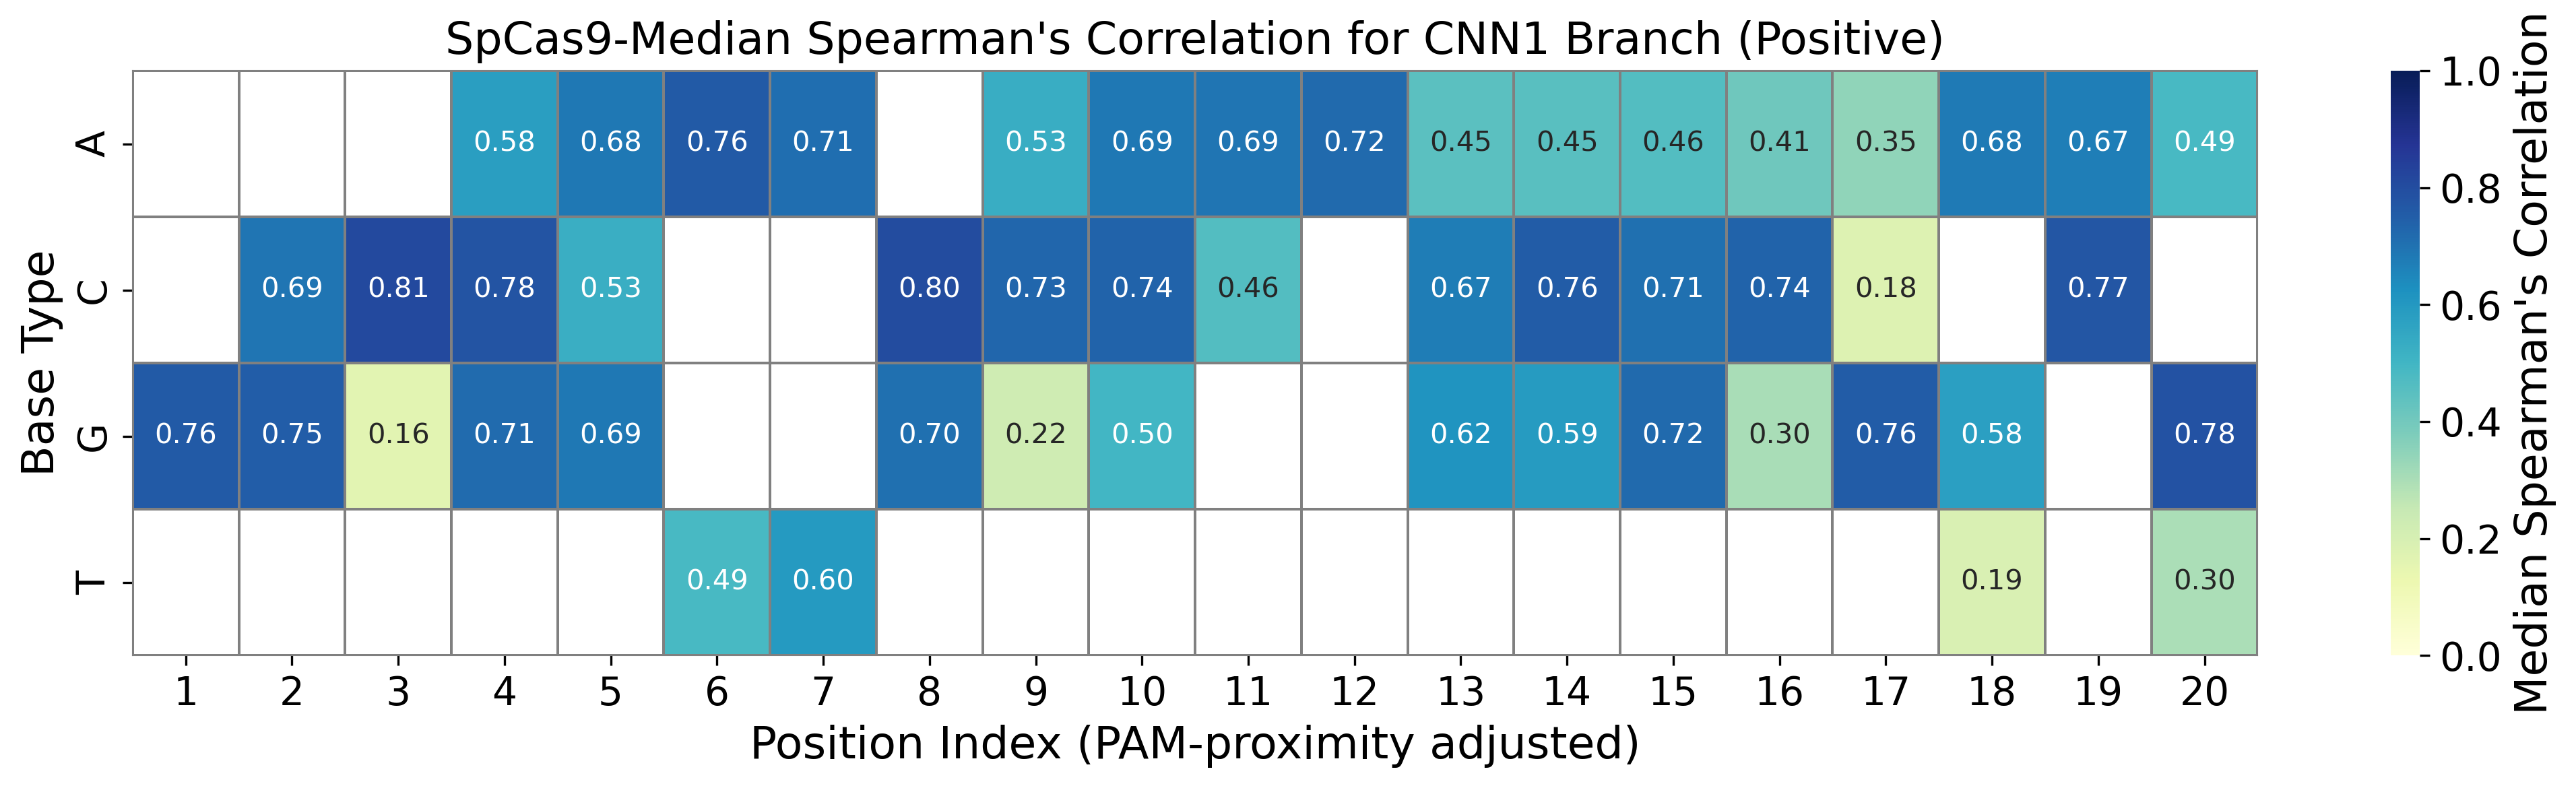

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load processed feature list
iqr_df = pd.read_csv("features_with_positive_IQR_Cas9_cnn1.csv")
iqr_df[['Pos', 'Base']] = iqr_df['Feature'].str.extract(r'Pos(\d+)_(\w)')
iqr_df['Pos'] = iqr_df['Pos'].astype(int)

# Pivot to heatmap format
heatmap_data = iqr_df.pivot(index="Base", columns="Pos", values="Median Spearman Correlation")

# Ensure all expected position indices are shown (e.g., 1–max observed)
full_pos_range = range(iqr_df['Pos'].min(), iqr_df['Pos'].max() + 1)
heatmap_data = heatmap_data.reindex(columns=full_pos_range)
heatmap_data = heatmap_data.loc[:, heatmap_data.columns[::-1]]


mask = heatmap_data.isna()

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 4), dpi=300)
hm = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Median Spearman Correlation"},
    linewidths=0.5,
    linecolor='gray',
    square=False,
    mask=mask,
    ax=ax
)

n_pos = heatmap_data.shape[1]
ax.set_xticks(np.arange(n_pos) + 0.5)
ax.set_xticklabels(range(1, n_pos + 1), fontsize=14)


# === Fix for missing bottom and right borders ===
# Turn on all spines (border lines)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_color('gray')


# Set custom font sizes
ax.set_xlabel("Position Index (PAM-proximity adjusted)", fontsize=16)
ax.set_ylabel("Base Type", fontsize=16)
ax.set_title("SpCas9-Median Spearman's Correlation for CNN1 Branch (Positive)", fontsize=16)

# Set tick label sizes
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

# === Adjust colorbar font sizes ===
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)  # Colorbar tick labels
cbar.set_label("Median Spearman's Correlation", fontsize=16)  # Colorbar title

plt.tight_layout()
plt.show()


In [9]:
import pandas as pd

# Disable truncation in Jupyter output
pd.set_option('display.max_rows', None)          # Show all rows
pd.set_option('display.max_columns', None)       # Show all columns
pd.set_option('display.width', None)             # Don't wrap lines
pd.set_option('display.max_colwidth', None)      # Show full content of each column

# === Load and preprocess ===
df = pd.read_csv("spearman_duplicates_grouped_norepeat_Cas9_cnn2.csv")

# Fill down missing edge names
df['Feature'] = df['Feature'].fillna(method='ffill')

# Preserve original feature order
original_order = df['Feature'].dropna().unique()
df['Feature'] = pd.Categorical(df['Feature'], categories=original_order, ordered=True)

# Group and filter
results = []

for feature in original_order:
    group = df[df['Feature'] == feature]
    spearman_values = group["Spearman Correlation"].dropna()

    if len(spearman_values) >= 2:
        q1 = spearman_values.quantile(0.25)
        q3 = spearman_values.quantile(0.75)
        median = spearman_values.median()

        if q1 > 0:
            results.append((feature, round(q1, 3), round(q3, 3), round(median, 3)))

# Output as DataFrame with original order preserved
iqr_df = pd.DataFrame(results, columns=["Feature", "Q1", "Q3", "Median Spearman Correlation"])
iqr_df["Feature"] = pd.Categorical(iqr_df["Feature"], categories=original_order, ordered=True)
iqr_df = iqr_df.sort_values("Feature")

# Display and save
print(iqr_df)
iqr_df.to_csv("features_with_positive_IQR_Cas9_cnn2.csv", index=False)


                   Feature     Q1     Q3  Median Spearman Correlation
0      Pos1_Paired-Opening  0.714  0.719                        0.719
1      Pos2_Paired-Opening  0.829  0.829                        0.829
2      Pos3_Paired-Opening  0.859  0.860                        0.860
3      Pos4_Paired-Opening  0.150  0.758                        0.450
4            Pos5_Unpaired  0.565  0.836                        0.785
5      Pos7_Paired-Opening  0.257  0.855                        0.561
6      Pos8_Paired-Opening  0.669  0.860                        0.860
7      Pos9_Paired-Opening  0.861  0.862                        0.862
8           Pos10_Unpaired  0.674  0.850                        0.849
9           Pos11_Unpaired  0.842  0.842                        0.842
10          Pos12_Unpaired  0.454  0.803                        0.707
11    Pos13_Paired-Opening  0.826  0.854                        0.845
12          Pos14_Unpaired  0.809  0.841                        0.840
13          Pos15_Un

/var/folders/8p/2p_212ld2qvgjsycxk_lmmg00000gn/T/ipykernel_58898/2810102351.py:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Feature'] = df['Feature'].fillna(method='ffill')


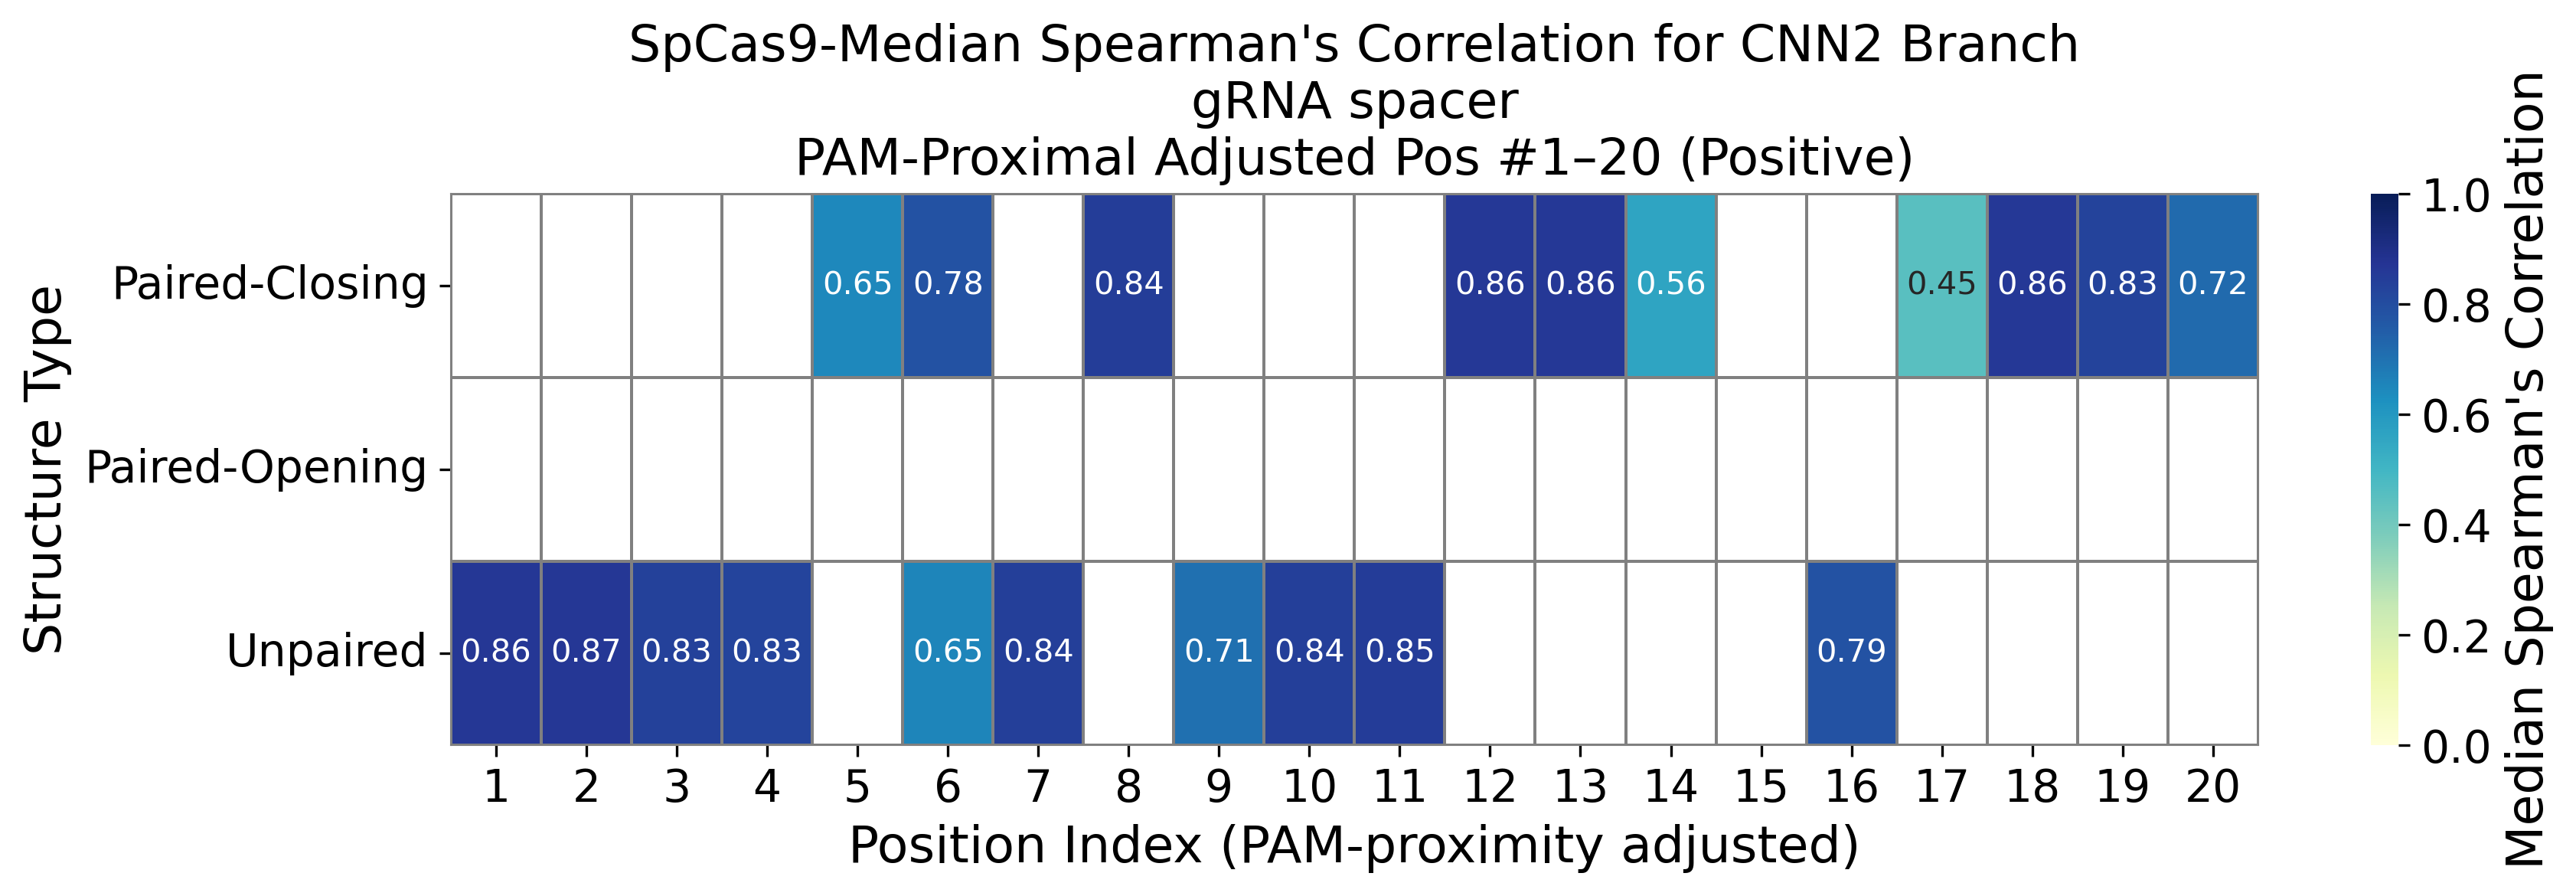

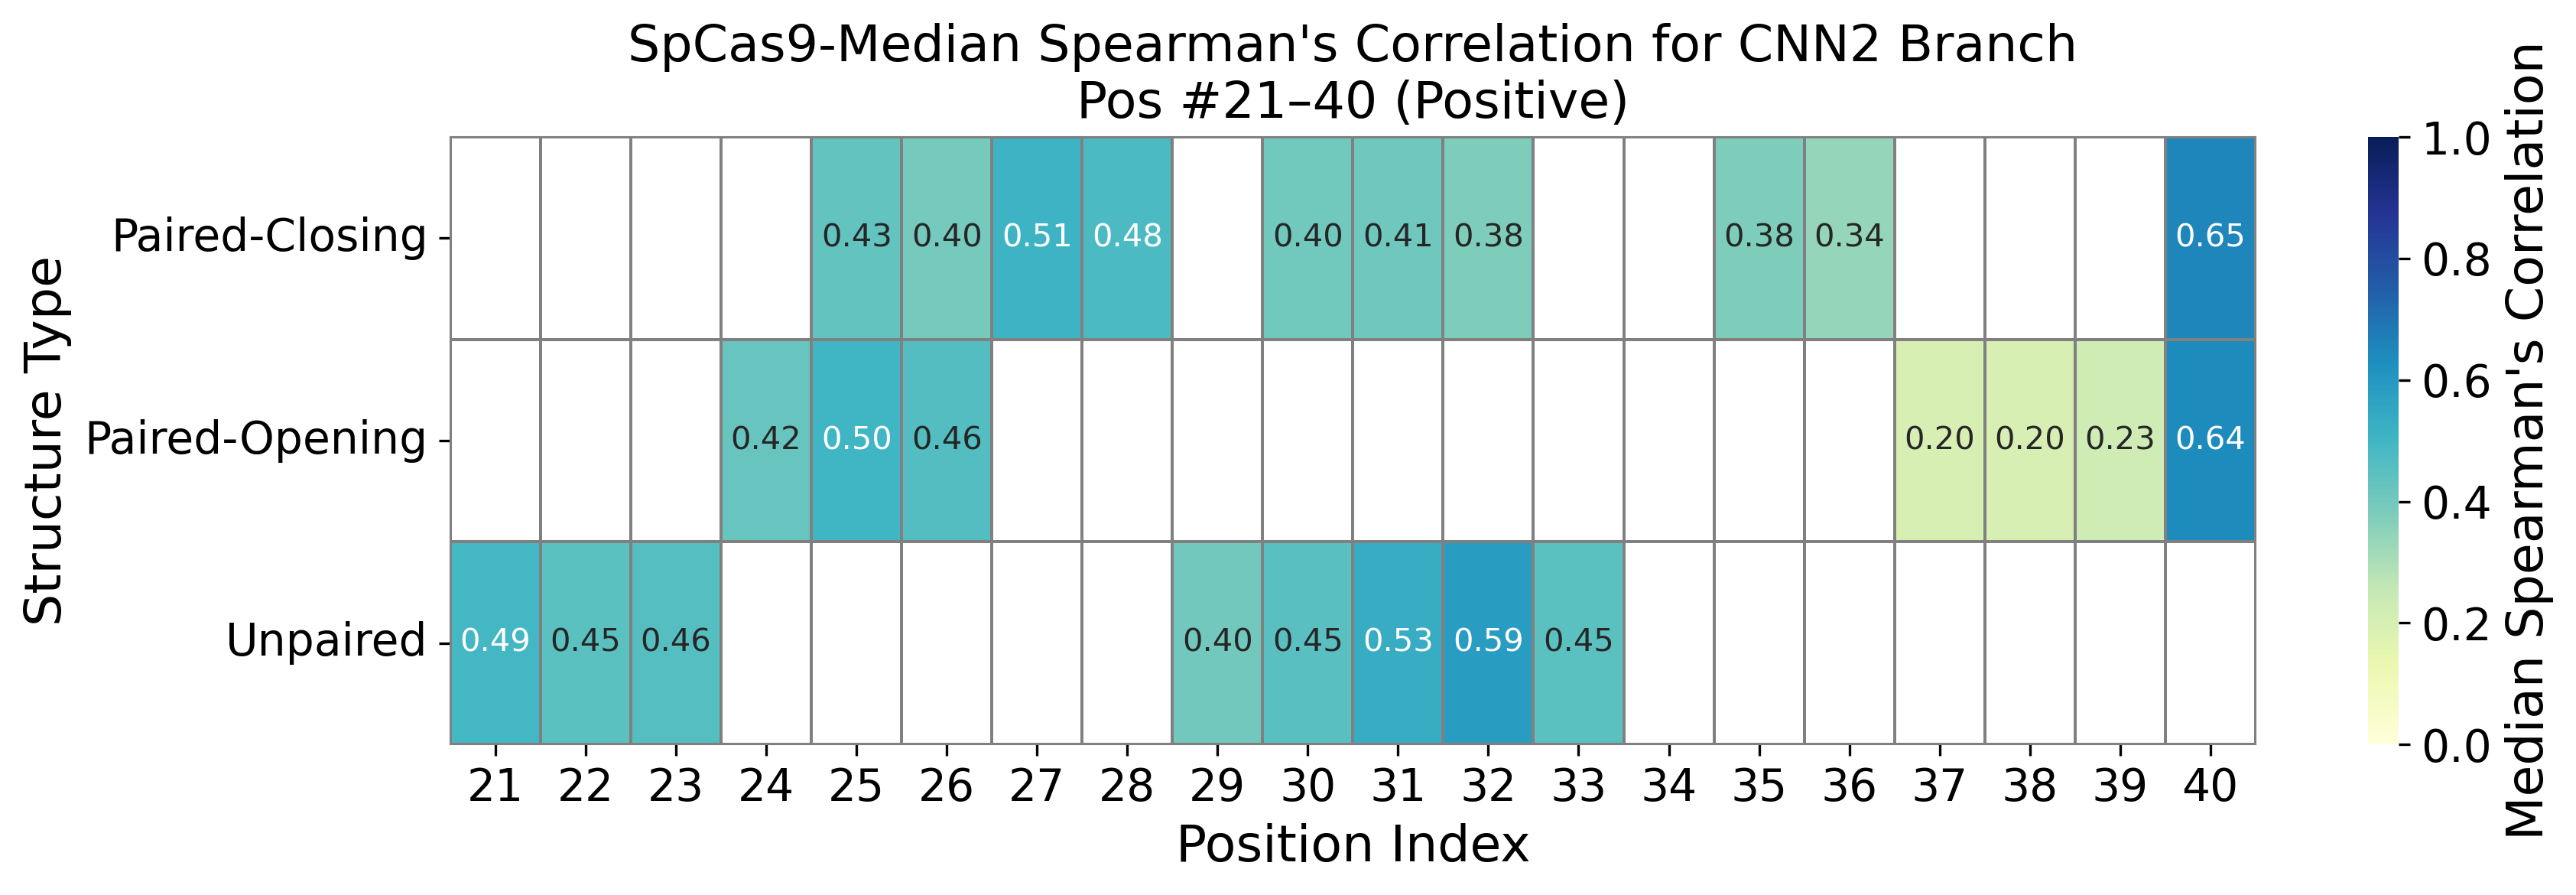

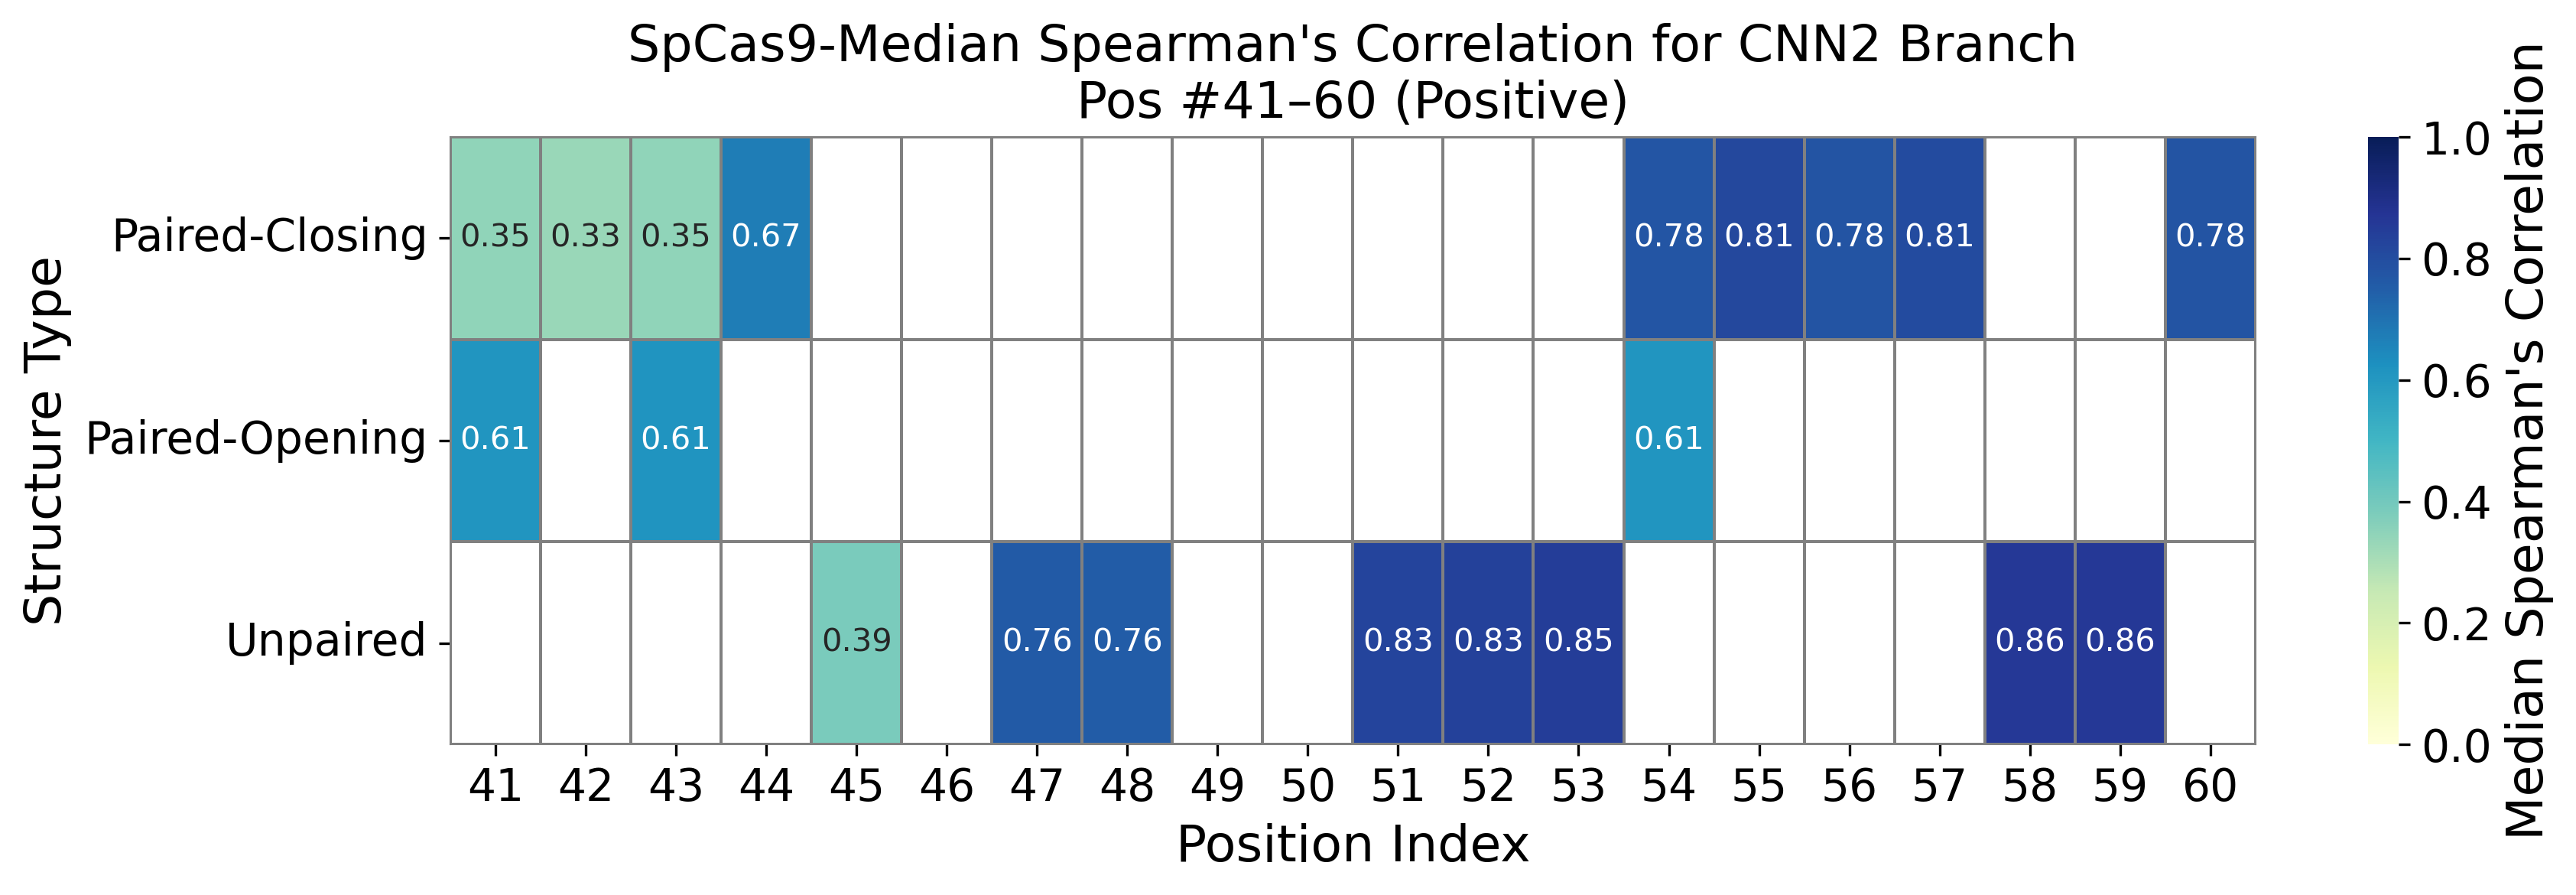

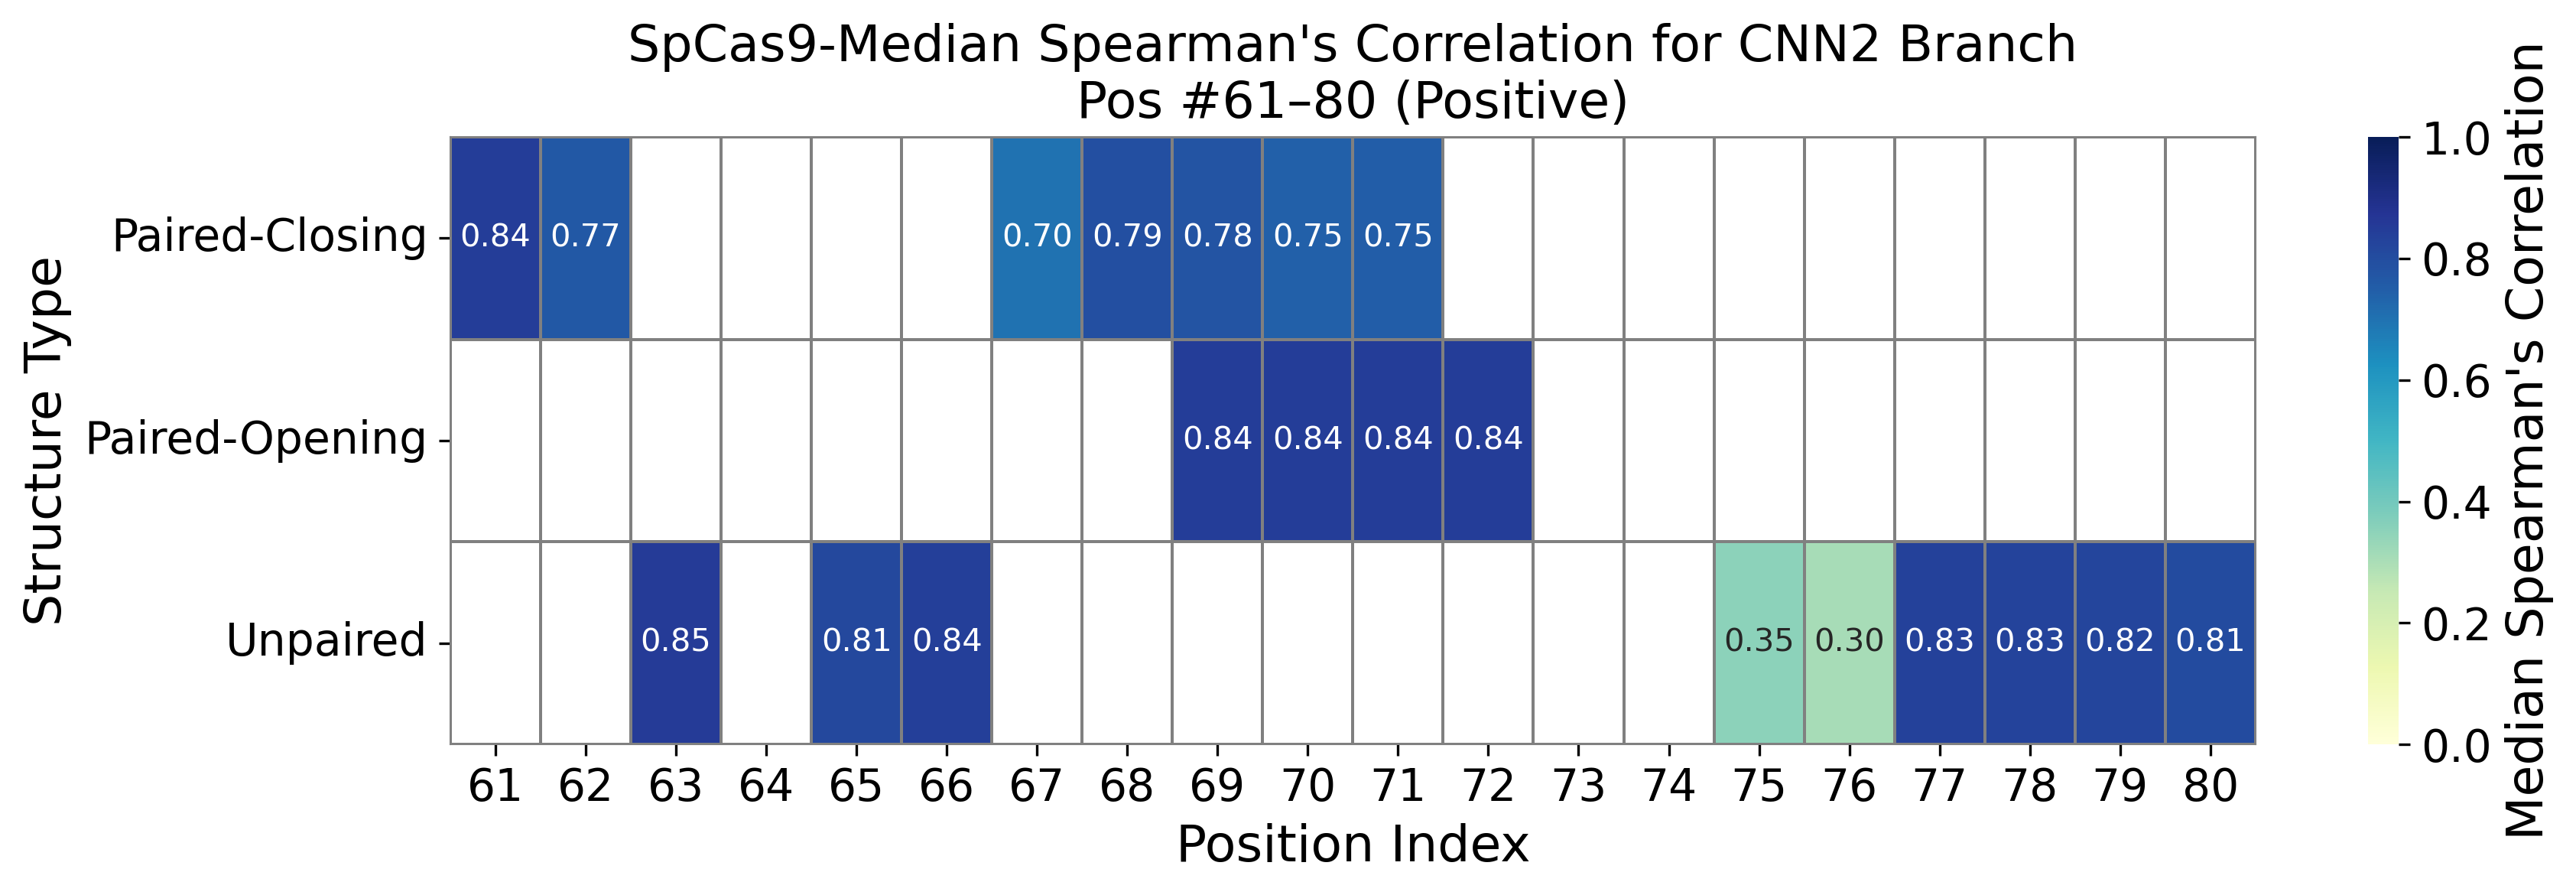

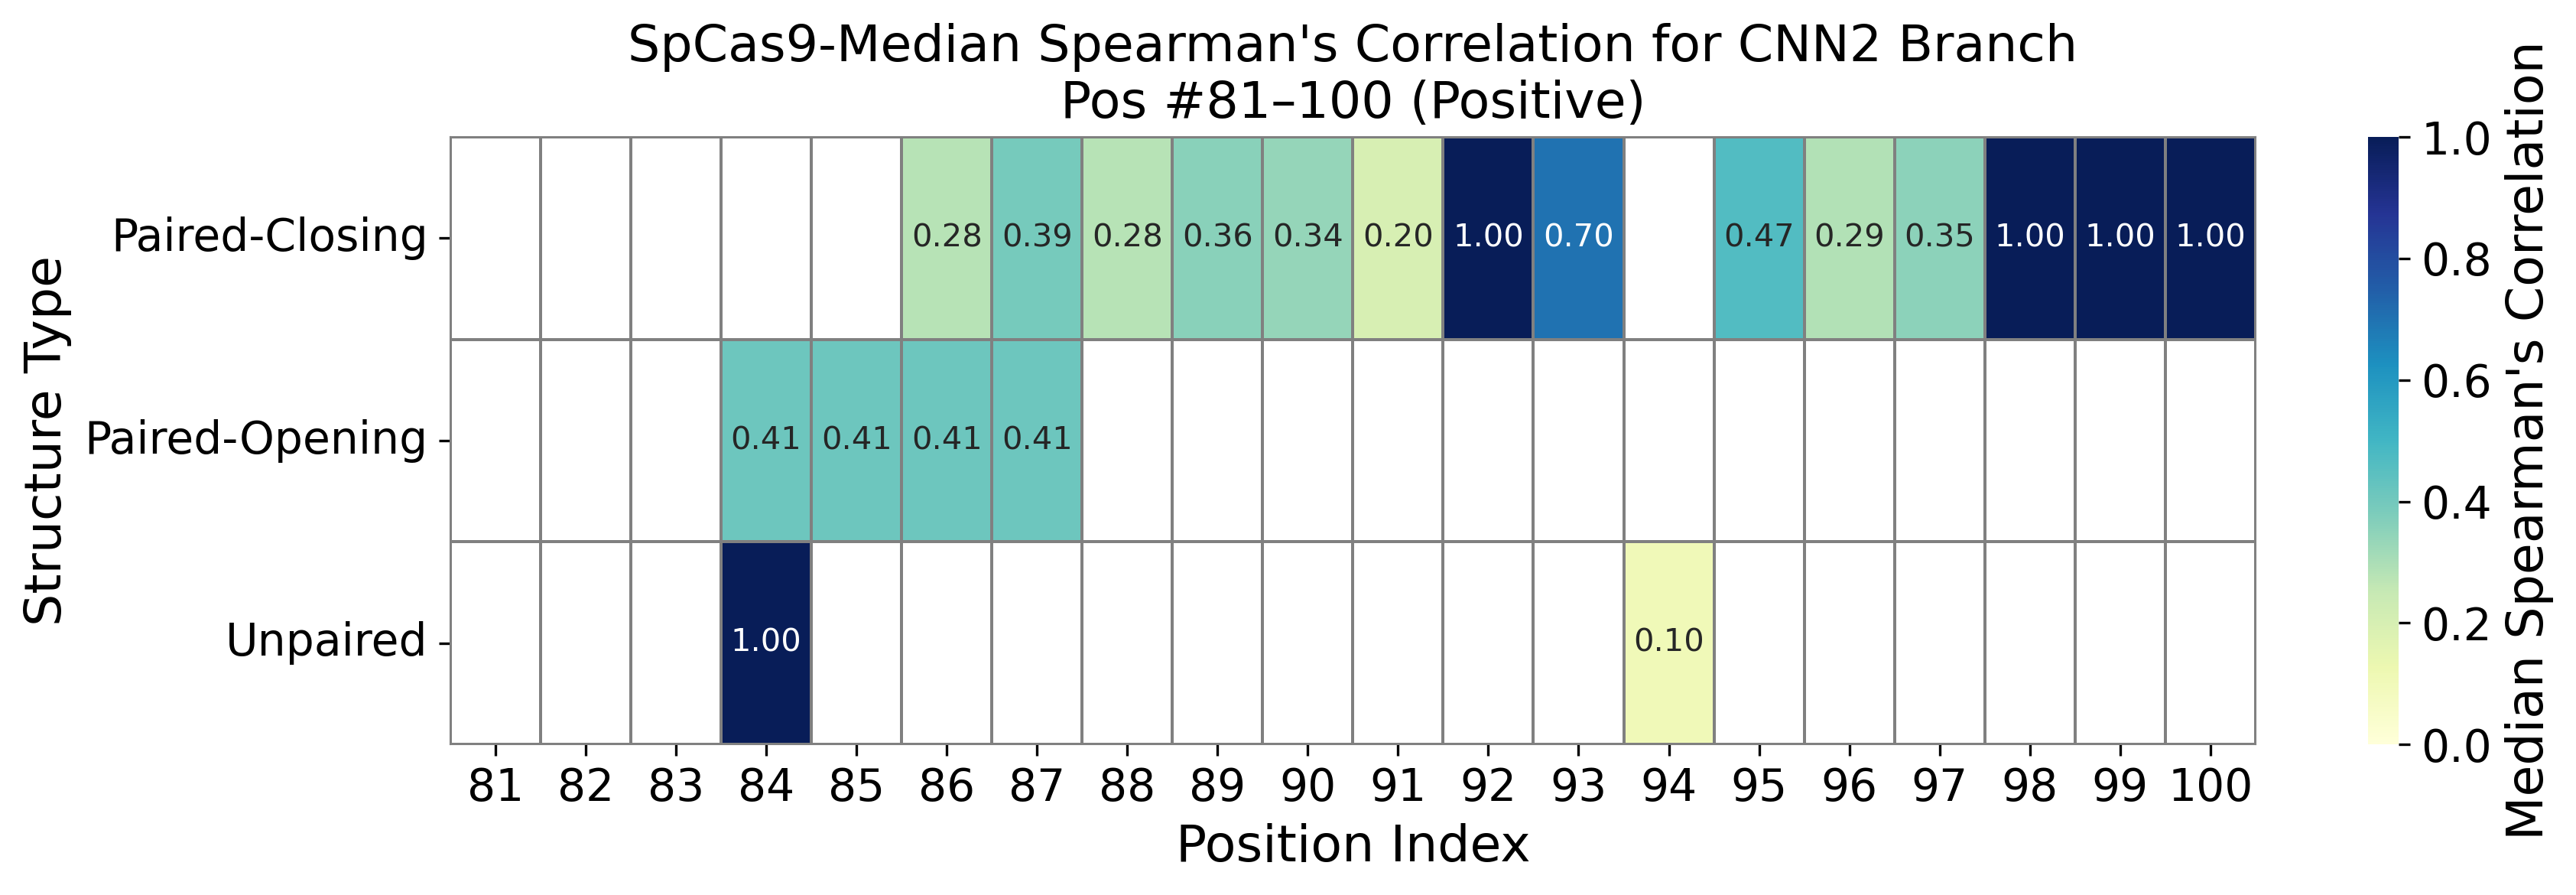

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# === Load processed feature list ===
iqr_df = pd.read_csv("features_with_positive_IQR_Cas9_cnn2.csv")

# === Extract Pos and Base Type (here Base = sub-feature like Paired, Opening, etc.) ===
iqr_df[['Pos', 'Base']] = iqr_df['Feature'].str.extract(r'Pos(\d+)_(.+)')
iqr_df['Pos'] = iqr_df['Pos'].astype(int)

# === Handle duplicate (Base, Pos) entries by averaging ===
iqr_df_grouped = iqr_df.groupby(['Base', 'Pos'])["Median Spearman Correlation"].mean().reset_index()

# === Pivot to heatmap format ===
heatmap_data = iqr_df_grouped.pivot(index="Base", columns="Pos", values="Median Spearman Correlation")

# Optional: Set fixed row order
row_order = sorted(heatmap_data.index.unique())
heatmap_data = heatmap_data.reindex(row_order)

# Ensure all expected position indices are shown (e.g., 1–max observed)
full_pos_range = range(iqr_df['Pos'].min(), iqr_df['Pos'].max() + 1)
heatmap_data = heatmap_data.reindex(columns=full_pos_range)

# Create mask for missing values
mask = heatmap_data.isna()

# === Create two heatmap panels ===

# === Heatmap for positions 1–20 (PAM-proximity adjusted) ===

# Extract and reverse ONLY this block

hm_1_20 = heatmap_data.loc[:, 1:20].copy()

# ---- Swap data of top and middle rows (labels unchanged) ----
row_labels = hm_1_20.index.tolist()

if len(row_labels) >= 2:
    r0, r1 = row_labels[0], row_labels[1]
    hm_1_20.loc[[r0, r1]] = hm_1_20.loc[[r1, r0]].values


hm_1_20 = hm_1_20.iloc[:, ::-1]

fig1, ax1 = plt.subplots(figsize=(12, 4), dpi=300)
hm1 = sns.heatmap(
    hm_1_20,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Median Spearman's Correlation"},
    linewidths=0.5,
    linecolor='gray',
    square=False,
    mask=hm_1_20.isna(),
    ax=ax1
)

# ---- Fix x-axis: display 1–20 AFTER reversal ----
n_pos = hm_1_20.shape[1]
ax1.set_xticks(np.arange(n_pos) + 0.5)
ax1.set_xticklabels(range(1, n_pos + 1), fontsize=14)

# ---- Y ticks horizontal ----
ax1.tick_params(axis='y', labelrotation=0)

# Borders
for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_color('gray')

ax1.set_xlabel("Position Index (PAM-proximity adjusted)", fontsize=16)
ax1.set_ylabel("Structure Type", fontsize=16)

ax1.set_title(
    "SpCas9-Median Spearman's Correlation for CNN2 Branch\n"
    'gRNA spacer\n'
    "PAM-Proximal Adjusted Pos #1–20 (Positive)",
    fontsize=16
)


ax1.tick_params(axis='x', labelsize=14)
ax1.tick_params(axis='y', labelsize=14, labelrotation=0)

cbar1 = hm1.collections[0].colorbar
cbar1.ax.tick_params(labelsize=14)
cbar1.set_label("Median Spearman's Correlation", fontsize=16)

plt.tight_layout()
plt.show()





# Heatmap for positions 21–40
fig2, ax2 = plt.subplots(figsize=(12, 4), dpi=300)
hm2 = sns.heatmap(
    heatmap_data.loc[:, 21:40],
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Median Spearman's Correlation"},
    linewidths=0.5,
    linecolor='gray',
    square=False,
    mask=heatmap_data.loc[:, 21:40].isna(),
    ax=ax2
)

for spine in ax2.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_color('gray')

ax2.set_xlabel("Position Index", fontsize=16)
ax2.set_ylabel("Structure Type", fontsize=16)
ax2.set_title(
    "SpCas9-Median Spearman's Correlation for CNN2 Branch\n"
    "Pos #21–40 (Positive)",
    fontsize=16
)
ax2.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14, labelrotation=0)

cbar2 = hm2.collections[0].colorbar
cbar2.ax.tick_params(labelsize=14)
cbar2.set_label("Median Spearman's Correlation", fontsize=16)

plt.tight_layout()
plt.show()


# Heatmap for positions 41–60
fig2, ax2 = plt.subplots(figsize=(12, 4), dpi=300)
hm2 = sns.heatmap(
    heatmap_data.loc[:, 41:60],
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Median Spearman's Correlation"},
    linewidths=0.5,
    linecolor='gray',
    square=False,
    mask=heatmap_data.loc[:, 41:60].isna(),
    ax=ax2
)

for spine in ax2.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_color('gray')

ax2.set_xlabel("Position Index", fontsize=16)
ax2.set_ylabel("Structure Type", fontsize=16)
ax2.set_title(
    "SpCas9-Median Spearman's Correlation for CNN2 Branch\n"
    "Pos #41–60 (Positive)",
    fontsize=16
)
ax2.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14, labelrotation=0)

cbar2 = hm2.collections[0].colorbar
cbar2.ax.tick_params(labelsize=14)
cbar2.set_label("Median Spearman's Correlation", fontsize=16)

plt.tight_layout()
plt.show()

# Heatmap for positions 61–80
fig2, ax2 = plt.subplots(figsize=(12, 4), dpi=300)
hm2 = sns.heatmap(
    heatmap_data.loc[:, 61:80],
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Median Spearman's Correlation"},
    linewidths=0.5,
    linecolor='gray',
    square=False,
    mask=heatmap_data.loc[:, 61:80].isna(),
    ax=ax2
)

for spine in ax2.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_color('gray')

ax2.set_xlabel("Position Index", fontsize=16)
ax2.set_ylabel("Structure Type", fontsize=16)
ax2.set_title(
    "SpCas9-Median Spearman's Correlation for CNN2 Branch\n"
    "Pos #61–80 (Positive)",
    fontsize=16
)
ax2.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14, labelrotation=0)

cbar2 = hm2.collections[0].colorbar
cbar2.ax.tick_params(labelsize=14)
cbar2.set_label("Median Spearman's Correlation", fontsize=16)

plt.tight_layout()
plt.show()


# Heatmap for positions 81–100
fig2, ax2 = plt.subplots(figsize=(12, 4), dpi=300)
hm2 = sns.heatmap(
    heatmap_data.loc[:, 81:100],
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Median Spearman's Correlation"},
    linewidths=0.5,
    linecolor='gray',
    square=False,
    mask=heatmap_data.loc[:, 81:100].isna(),
    ax=ax2
)

for spine in ax2.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_color('gray')

ax2.set_xlabel("Position Index", fontsize=16)
ax2.set_ylabel("Structure Type", fontsize=16)
ax2.set_title(
    "SpCas9-Median Spearman's Correlation for CNN2 Branch\n"
    "Pos #81–100 (Positive)",
    fontsize=16
)
ax2.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14, labelrotation=0)

cbar2 = hm2.collections[0].colorbar
cbar2.ax.tick_params(labelsize=14)
cbar2.set_label("Median Spearman's Correlation", fontsize=16)

plt.tight_layout()
plt.show()
